# Build 01: Explore data distribution drift in each model version 


In [1]:
from pathlib import Path 

import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 

ROOT = Path.cwd() 
while not (ROOT / "src" / "data" / "synthetic" / "run.py" ).exists() and ROOT != ROOT.parent: 
    ROOT = ROOT.parent 

PARQUET = ROOT / "src" / "data" / "synthetic" / "generate" / "parquet"

pre_v1 = pd.read_parquet(PARQUET / "claims_pre_v1.parquet")
log = pd.read_parquet(PARQUET / "claims_v1_log.parquet")

In [2]:
# 2016-2021
print(f"claims_pre_v1: {len(pre_v1):}") 

#2022-2024
print(f"claims_v1_log: {len(log):}") 

      

claims_pre_v1: 46775
claims_v1_log: 23225


# P15

## 1. Score drift & 2.  Scrap rate drift 

In [3]:
mean_scores = {"v1": log.model_v1_score.mean(),    "v2a": log.model_v2a_score.mean(),    "v2b": log.model_v2b_score.mean(), "v3a": log.model_v3a_score.mean(),    "v3ㅠ": log.model_v3b_score.mean()}
print(mean_scores)

decision_rates  = {"v1": log.model_v1_decision.mean(), "v2a": log.model_v2a_decision.mean(), "v2b": log.model_v2b_decision.mean(), "v3a": log.model_v3a_decision.mean(), "v3b": log.model_v3b_decision.mean()}
print(decision_rates)

table = pd.DataFrame({"version": decision_rates.keys(), 
                      "scrap_decision_rate": [round(v, 3) for v in decision_rates.values()],
                      "mean_score": [round(v, 3) for v in mean_scores.values()]})
print(table.to_string())

{'v1': np.float32(0.19157648), 'v2a': np.float32(0.1899236), 'v2b': np.float32(0.19241162), 'v3a': np.float32(0.18272735), 'v3ㅠ': np.float32(0.18293305)}
{'v1': np.float64(0.1477287405812702), 'v2a': np.float64(0.15130247578040903), 'v2b': np.float64(0.15138858988159312), 'v3a': np.float64(0.15233584499461786), 'v3b': np.float64(0.15522066738428417)}
  version  scrap_decision_rate  mean_score
0      v1                0.148       0.192
1     v2a                0.151       0.190
2     v2b                0.151       0.192
3     v3a                0.152       0.183
4     v3b                0.155       0.183


## Compare the rate of vehicles scrapped under garage decision. 

In [4]:
v1_scrap_decision = log.model_v1_decision == 1
v1_repair_decision = ~v1_scrap_decision
print("v1")
print(f"P(observed=1 | decision_scrap) = {log.loc[v1_scrap_decision, 'model_v1_observed_outcome'].mean():.3f}")
print(f"P(observed=1 | decision_repair)   = {log.loc[v1_repair_decision, 'model_v1_observed_outcome'].mean():.3f}")


v2a_scrap_decision = log.model_v2a_decision == 1
v2a_repair_decision = ~v2a_scrap_decision
print("v2a")
print(f"P(observed=1 | decision_scrap) = {log.loc[v2a_scrap_decision, 'model_v2a_observed_outcome'].mean():.3f}")
print(f"P(observed=1 | decision_repair)   = {log.loc[v2a_repair_decision, 'model_v2a_observed_outcome'].mean():.3f}")

v3a_scrap_decision = log.model_v3a_decision == 1
v3a_repair_decision = ~v3a_scrap_decision
print("v3a")
print(f"P(observed=1 | decision_scrap) = {log.loc[v3a_scrap_decision, 'model_v3a_observed_outcome'].mean():.3f}")
print(f"P(observed=1 | decision_repair)   = {log.loc[v3a_repair_decision, 'model_v3a_observed_outcome'].mean():.3f}")

v2b_scrap_decision = log.model_v2b_decision == 1
v2b_repair_decision = ~v2b_scrap_decision
print("v2b")
print(f"P(observed=1 | decision_scrap) = {log.loc[v2b_scrap_decision, 'model_v2b_observed_outcome'].mean():.3f}")
print(f"P(observed=1 | decision_repair)   = {log.loc[v2b_repair_decision, 'model_v2b_observed_outcome'].mean():.3f}")

v3b_scrap_decision = log.model_v3b_decision == 1
v3b_repair_decision = ~v3b_scrap_decision
print("v3b")
print(f"P(observed=1 | decision_scrap) = {log.loc[v3b_scrap_decision, 'model_v3b_observed_outcome'].mean():.3f}")
print(f"P(observed=1 | decision_repair)   = {log.loc[v3b_repair_decision, 'model_v3b_observed_outcome'].mean():.3f}")


v1
P(observed=1 | decision_scrap) = 1.000
P(observed=1 | decision_repair)   = 0.052
v2a
P(observed=1 | decision_scrap) = 1.000
P(observed=1 | decision_repair)   = 0.047
v3a
P(observed=1 | decision_scrap) = 1.000
P(observed=1 | decision_repair)   = 0.046
v2b
P(observed=1 | decision_scrap) = 1.000
P(observed=1 | decision_repair)   = 0.047
v3b
P(observed=1 | decision_scrap) = 1.000
P(observed=1 | decision_repair)   = 0.044


### Decision flipped in v# models

In [5]:
v1_scrap_decision = log.model_v1_decision == 1
v1_repair_decision = ~v1_scrap_decision 
print(f"v1 total repair decision: {v1_repair_decision.sum()}")

v1 total repair decision: 19794


In [6]:
flip_v2a = v1_repair_decision & (log.model_v2a_decision == 1)
flip_v2b = v1_repair_decision & (log.model_v2b_decision == 1)


flip_v3a = v1_repair_decision & (log.model_v3a_decision == 1)
flip_v3b = v1_repair_decision & (log.model_v3b_decision == 1)


In [7]:
# flipped decision v1 >> v2
print(f"v1-repair >> v2a-scrap: {flip_v2a.sum():,} ({flip_v2a.sum() / v1_repair_decision.sum():.1%})")
print(f"v1-repair >> v2b-scrap: {flip_v2b.sum():,} ({flip_v2b.sum() / v1_repair_decision.sum():.1%})")


v1-repair >> v2a-scrap: 146 (0.7%)
v1-repair >> v2b-scrap: 134 (0.7%)


In [8]:
# flipped decision v1 >> v3
print(f"v1-repair >> v3a-scrap: {flip_v3a.sum():,} ({flip_v3a.sum() / v1_repair_decision.sum():.1%})")
print(f"v1-repair >> v3b-scrap: {flip_v3b.sum():,} ({flip_v3b.sum() / v1_repair_decision.sum():.1%})")


v1-repair >> v3a-scrap: 176 (0.9%)
v1-repair >> v3b-scrap: 224 (1.1%)


## Score distribution 

### v1, v2a, v3a

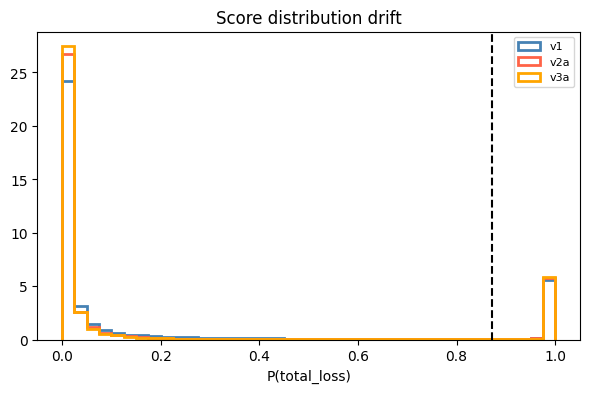

In [9]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(log["model_v1_score"], bins=40, histtype="step", lw=2, color="steelblue", density=True, label="v1")
ax.hist(log["model_v2a_score"], bins=40, histtype="step", lw=2, color="tomato", density=True, label="v2a")
ax.hist(log["model_v3a_score"], bins=40, histtype="step", lw=2, color="orange", density=True, label="v3a")
ax.axvline(0.872, ls="--", color="k"); ax.set_title("Score distribution drift")
ax.set_xlabel("P(total_loss)"); ax.legend(fontsize=8)
plt.show()

### v1, v2b, v3b

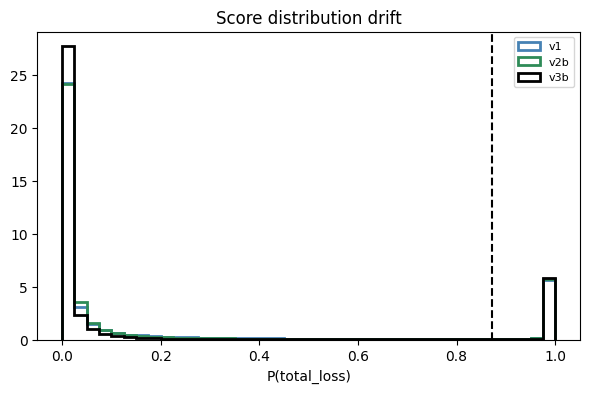

In [10]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(log["model_v1_score"], bins=40, histtype="step", lw=2, color="steelblue", density=True, label="v1")
ax.hist(log["model_v2b_score"], bins=40, histtype="step", lw=2, color="seagreen", density=True, label="v2b")
ax.hist(log["model_v3b_score"], bins=40, histtype="step", lw=2, color="black", density=True, label="v3b")
ax.axvline(0.872, ls="--", color="k"); ax.set_title("Score distribution drift")
ax.set_xlabel("P(total_loss)"); ax.legend(fontsize=8)
plt.show()

### v1, v2a, v2b

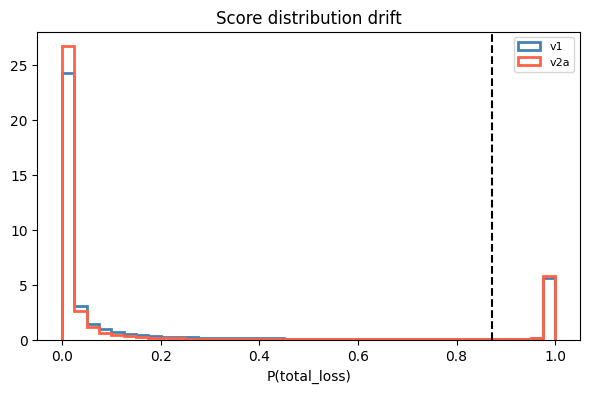

In [11]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(log["model_v1_score"], bins=40, histtype="step", lw=2, color="steelblue", density=True, label="v1")
ax.hist(log["model_v2a_score"], bins=40, histtype="step", lw=2, color="tomato", density=True, label="v2a")
# ax.hist(log["model_v2b_score"], bins=40, histtype="step", lw=2, color="seagreen", density=True, label="v2b")
ax.axvline(0.872, ls="--", color="k"); ax.set_title("Score distribution drift")
ax.set_xlabel("P(total_loss)"); ax.legend(fontsize=8)
plt.show()

### v1, v3a, v3b

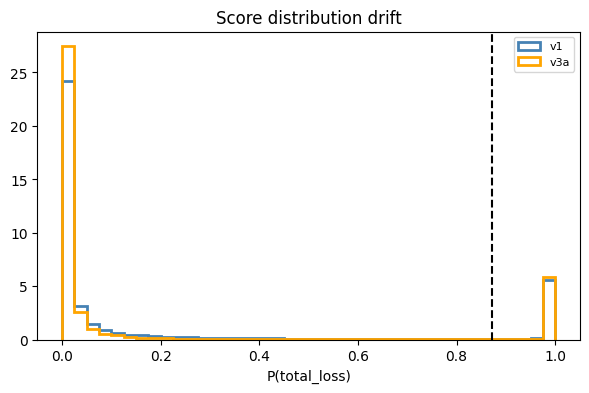

In [12]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(log["model_v1_score"], bins=40, histtype="step", lw=2, color="steelblue", density=True, label="v1")
ax.hist(log["model_v3a_score"], bins=40, histtype="step", lw=2, color="orange", density=True, label="v3a")
# ax.hist(log["model_v3b_score"], bins=40, histtype="step", lw=2, color="black", density=True, label="v3b")

ax.axvline(0.872, ls="--", color="k"); ax.set_title("Score distribution drift")
ax.set_xlabel("P(total_loss)"); ax.legend(fontsize=8)
plt.show()

# TODO: 
- need to prove the distribution shift is significant. 
- need to prove this distribution shift is due to SFP loop mathematically >> read p12 
- how to analyse features X drift with inflation 

value vehicle rising >> repair to value ratio  